# 모델 2. 추천 점수 예측 모델

이 노트북은 **모델 1에서 생성한 관광지 유형별 확률 데이터**를 활용하여 관광지별 추천 점수를 만들고, 그 점수를 예측하는 회귀 모델을 학습합니다.

## 목표
- 입력: 관광지 기본 정보 + 모델 1 유형 확률 + 방문자/체류/숙박/내비게이션/소비 데이터
- 출력: `recommend_score`, `predicted_recommend_score`, 추천 순위
- 모델: `RandomForestRegressor`

> 현재는 실제 사용자 평점/클릭 로그가 없기 때문에 `recommend_score`는 공공데이터 기반 **의사 라벨(pseudo-label)**입니다.


In [1]:
import os, re, json, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
import unicodedata

BASE_DIR = Path("..").resolve()

DATA_DIR = BASE_DIR / "Data"
RECOMMEND_DIR = DATA_DIR / "recommend_score"

MODEL1_OUTPUT_DIR = Path("tourism_type_model_outputs")
MODEL2_OUTPUT_DIR = Path("recommend_score_model_outputs")
MODEL2_OUTPUT_DIR.mkdir(exist_ok=True)

MODEL1_DATA_PATH = MODEL1_OUTPUT_DIR / "namyangju_dataset_with_type_probabilities.csv"

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("BASE_DIR:", BASE_DIR)
print("RECOMMEND_DIR exists:", RECOMMEND_DIR.exists())
print("MODEL1_DATA_PATH exists:", MODEL1_DATA_PATH.exists())

BASE_DIR: /Users/jy-kim/Documents/GitHub/KTO
RECOMMEND_DIR exists: True
MODEL1_DATA_PATH exists: True


## 1. 데이터 파일 찾기
모델 2는 모델 1의 결과 파일인 `namyangju_dataset_with_type_probabilities.csv`를 우선 사용합니다.

In [2]:
def normalize_text(text):
    """
    macOS 한글 파일명 정규화 문제를 줄이기 위한 함수.
    """
    return unicodedata.normalize("NFC", str(text))


def read_csv_auto(path):
    """
    CSV 인코딩이 utf-8-sig, utf-8, cp949, euc-kr 중 무엇인지 몰라도 읽기 위한 함수.
    """
    path = Path(path)
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as e:
            last_error = e

    raise last_error


def to_numeric_series(series):
    """
    쉼표, %, 공백 등이 섞인 문자열 컬럼을 숫자형으로 변환.
    """
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )


def minmax(series):
    """
    0~1 정규화. 값이 모두 같거나 비어 있으면 0으로 반환.
    """
    s = pd.to_numeric(series, errors="coerce")
    min_v = s.min()
    max_v = s.max()

    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(np.zeros(len(s)), index=s.index)

    return (s - min_v) / (max_v - min_v)


def find_file_by_keywords(directory, keywords, exclude_keywords=None, suffix=".csv", verbose=True):
    """
    directory 안에서 keywords가 모두 포함되고,
    exclude_keywords가 포함되지 않은 CSV 파일을 찾는다.
    """
    directory = Path(directory)
    keywords = [normalize_text(k) for k in keywords]
    exclude_keywords = exclude_keywords or []
    exclude_keywords = [normalize_text(k) for k in exclude_keywords]

    candidates = []

    for path in directory.glob(f"*{suffix}"):
        normalized_name = normalize_text(path.name)

        include_ok = all(keyword in normalized_name for keyword in keywords)
        exclude_ok = not any(keyword in normalized_name for keyword in exclude_keywords)

        if include_ok and exclude_ok:
            candidates.append(path)

    if len(candidates) == 0:
        available_files = [p.name for p in directory.glob(f"*{suffix}")]
        raise FileNotFoundError(
            f"파일을 찾지 못했습니다.\n"
            f"검색 키워드: {keywords}\n"
            f"제외 키워드: {exclude_keywords}\n"
            f"검색 폴더: {directory}\n"
            f"사용 가능한 CSV 파일:\n" + "\n".join(available_files)
        )

    if len(candidates) > 1 and verbose:
        print("[주의] 여러 파일이 검색되었습니다. 첫 번째 파일을 사용합니다.")
        for c in candidates:
            print("-", c.name)

    if verbose:
        print("[선택된 파일]", candidates[0].name)

    return candidates[0]


In [3]:
visitor_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["방문자", "연인원"]
)

nav_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["내비게이션", "목적지", "검색량"]
)

stay_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["평균", "체류시간"]
)

overnight_days_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["평균", "숙박일"]
)

overnight_ratio_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["숙박방문자", "비율"]
)

unique_visitor_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["순", "방문자", "숙박", "비율"]
)

distance_visitor_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["거리별", "방문자"]
)

spending_domestic_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["관광소비", "내국인"]
)

spending_outsider_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["관광소비", "추이", "외지인"],
    exclude_keywords=["전국", "대비"]
)

spending_compare_outsider_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["전국", "대비", "관광소비", "외지인"]
)


local_currency_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["지역화폐"]
)

sns_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["SNS"]
)

paid_visitor_path = find_file_by_keywords(
    RECOMMEND_DIR,
    ["유료관광지점", "전체"]
)

[선택된 파일] 20260602152817_방문자 수(연인원) 추이.csv
[선택된 파일] 20260602152817_내비게이션 목적지 유형별 검색량 .csv
[선택된 파일] 20260602152826_평균 체류시간 추이.csv
[선택된 파일] 20260602152826_평균 숙박일.csv
[선택된 파일] 20260602152826_숙박방문자 비율 추이 .csv
[선택된 파일] 20260602152826_순 방문자 수 및 숙박 비율.csv
[선택된 파일] 20260602152817_거리별 방문자 분포.csv
[선택된 파일] 20260602152830_관광소비 추이_내국인.csv
[선택된 파일] 20260602152830_관광소비 추이_외지인.csv
[선택된 파일] 20260602152830_전국 대비 관광소비 추이_외지인.csv
[선택된 파일] 20260602152830_지역화폐 관광소비 추이.csv
[선택된 파일] 20260602152841_SNS 언급량.csv
[선택된 파일] 20260602152901_주요 유료관광지점 입장객 수_전체.csv


## 2. 모델 1 결과 데이터 불러오기
모델 1에서 생성된 유형별 확률 컬럼(`type_prob_...`)을 모델 2의 입력 변수로 사용합니다.

In [4]:
model1_path = MODEL1_DATA_PATH

if not model1_path.exists():
    raise FileNotFoundError(
        f"모델 1 결과 파일을 찾을 수 없습니다: {model1_path}\n"
        "먼저 src/target_tourism_type_all_existing_no_distance_infoscore.ipynb를 실행해서\n"
        "src/tourism_type_model_outputs/namyangju_dataset_with_type_probabilities.csv 파일을 생성하세요."
    )

df = read_csv_auto(model1_path)

print("사용 파일:", model1_path)
print("데이터 크기:", df.shape)
df.head()


사용 파일: tourism_type_model_outputs/namyangju_dataset_with_type_probabilities.csv
데이터 크기: (381, 65)


,addr1,addr2,areacode,cat1,cat2,cat3,contentid,contenttypeid,createdtime,firstimage,...,type_prob_쇼핑,type_prob_숙박,type_prob_역사관광,type_prob_음식,type_prob_자연관광,type_prob_체험관광,type_top1,type_top1_prob,type_top2,type_top2_prob
0,경기도 남양주시 강변북로632번길 57-28 (수석동),NaN,NaN,NaN,NaN,NaN,798518,39,20090907191546,https://tong.visitkorea.or.kr/cms/resource/99/...,...,0.033745,0.027832,0.014910,0.773090,0.016819,0.004160,음식,0.773090,문화관광,0.051657
1,경기도 남양주시 화도읍 북한강로1570번길 16,NaN,NaN,NaN,NaN,NaN,3045767,28,20231122100649,https://tong.visitkorea.or.kr/cms/resource/53/...,...,0.008095,0.008626,0.006355,0.004009,0.005783,0.002034,레저스포츠,0.921669,문화관광,0.024672
2,경기도 남양주시 수동면 비룡로 1603,NaN,31.0,A03,A0302,A03021700,2738718,28,20210901200909,http://tong.visitkorea.or.kr/cms/resource/41/2...,...,0.002752,0.046026,0.004869,0.002019,0.018245,0.001269,레저스포츠,0.911588,숙박,0.046026
3,경기도 남양주시 조안면 다산로747번길 45,NaN,31.0,A05,A0502,A05020100,133832,39,20040220090000,NaN,...,0.001232,0.002739,0.005527,0.955183,0.009861,0.007237,음식,0.955183,문화관광,0.011415
4,경기도 남양주시 와부읍 경강로 876,NaN,NaN,NaN,NaN,NaN,134729,39,20041201090000,NaN,...,0.006419,0.021244,0.004189,0.871384,0.012185,0.011342,음식,0.871384,문화관광,0.034784


In [5]:
drop_distance_cols = ['distance_from_namyangju_center_km','distance_from_center_km','access_score']
df = df.drop(columns=[col for col in drop_distance_cols if col in df.columns], errors='ignore')
print('거리 관련 컬럼 제거 후:', df.shape)
print([col for col in df.columns if 'distance' in col.lower() or 'access' in col.lower()])


거리 관련 컬럼 제거 후: (381, 65)
[]


In [6]:
# 모델 1 확률 컬럼 기준으로 top1/top2 유형이 없으면 생성합니다.
prob_cols_initial = [col for col in df.columns if col.startswith('type_prob_')]
if prob_cols_initial:
    prob_values = df[prob_cols_initial].apply(pd.to_numeric, errors='coerce').fillna(0)
    class_names_initial = [col.replace('type_prob_', '') for col in prob_cols_initial]
    top_order = np.argsort(-prob_values.values, axis=1)
    if 'type_top1' not in df.columns:
        df['type_top1'] = [class_names_initial[idxs[0]] for idxs in top_order]
    if 'type_top1_prob' not in df.columns:
        df['type_top1_prob'] = prob_values.max(axis=1)
    if 'type_top2' not in df.columns and len(prob_cols_initial) >= 2:
        df['type_top2'] = [class_names_initial[idxs[1]] for idxs in top_order]
    if 'type_top2_prob' not in df.columns and len(prob_cols_initial) >= 2:
        df['type_top2_prob'] = [prob_values.iloc[i, top_order[i, 1]] for i in range(len(df))]

print('모델 1 유형 확률 컬럼 수:', len(prob_cols_initial))
print('type_top1 존재 여부:', 'type_top1' in df.columns)


모델 1 유형 확률 컬럼 수: 9
type_top1 존재 여부: True


## 3. 관광지 기본 파생 변수 정리
`info_score`와 `recent_score`를 보조 변수로 사용합니다. `info_score`는 실제 관광 매력도를 직접 의미하지 않으므로 낮은 가중치로 반영합니다.

In [7]:
CONTENT_TYPE_MAP = {12:'관광지',14:'문화시설',15:'축제/공연/행사',25:'여행코스',28:'레포츠',32:'숙박',38:'쇼핑',39:'음식점'}
if 'content_type_name' not in df.columns:
    df['content_type_name'] = df['contenttypeid'].map(CONTENT_TYPE_MAP).fillna('기타')
for col in ['firstimage','firstimage2','tel','addr1','addr2','zipcode','mapx','mapy','contenttypeid','modifiedtime','title']:
    if col not in df.columns: df[col] = np.nan
for col in ['lclsSystm1','lclsSystm2','lclsSystm3','cat1','cat2','cat3']:
    if col not in df.columns: df[col] = np.nan
if 'info_score' not in df.columns:
    df['info_score'] = (
        df['title'].notna().astype(int)*10 + df['addr1'].notna().astype(int)*15 + df['addr2'].notna().astype(int)*5 +
        (df['mapx'].notna() & df['mapy'].notna()).astype(int)*15 + df['contenttypeid'].notna().astype(int)*10 +
        df[['lclsSystm1','lclsSystm2','lclsSystm3','cat1','cat2','cat3']].notna().any(axis=1).astype(int)*15 +
        df['firstimage'].notna().astype(int)*10 + df['firstimage2'].notna().astype(int)*5 + df['tel'].notna().astype(int)*5 +
        df['zipcode'].notna().astype(int)*5 + df['modifiedtime'].notna().astype(int)*5
    ) / 100
else:
    df['info_score'] = pd.to_numeric(df['info_score'], errors='coerce').fillna(0)
    if df['info_score'].max() > 1: df['info_score'] = df['info_score'] / 100
if 'recent_score' not in df.columns:
    modified = pd.to_datetime(df['modifiedtime'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
    days = (pd.Timestamp.today().normalize() - modified).dt.days
    df['recent_score'] = 1 - minmax(days.fillna(days.max()))
else:
    df['recent_score'] = pd.to_numeric(df['recent_score'], errors='coerce').fillna(0)
    if df['recent_score'].max() > 1: df['recent_score'] = minmax(df['recent_score'])
for new_col, base_col in [('has_image','firstimage'),('has_tel','tel'),('has_addr','addr1')]:
    if new_col not in df.columns: df[new_col] = df[base_col].notna().astype(int)
df[['title','content_type_name','info_score','recent_score','has_image','has_tel','has_addr']].head()


,title,content_type_name,info_score,recent_score,has_image,has_tel,has_addr
0,가든갤러리,음식점,0.90,0.948339,1,0,1
1,가람수상스키,레포츠,0.90,0.931734,1,0,1
2,가족쉼터,레포츠,0.90,0.322878,1,0,1
3,감나무집,음식점,0.75,0.250923,0,0,1
4,개성집,음식점,0.75,0.891144,0,0,1


## 4. 외부 관광 수요 데이터 요약 변수 생성
방문자 수, 체류시간, 숙박일, 숙박방문자 비율, 관광소비 등을 요약합니다.

In [8]:
paths = {
    "visitor": visitor_path,
    "stay": stay_path,
    "overnight_days": overnight_days_path,
    "overnight_ratio": overnight_ratio_path,
    "unique_visitor": unique_visitor_path,
    "distance_visitor": distance_visitor_path,
    "nav_volume": nav_path,
    "spending_domestic": spending_domestic_path,
    "spending_outsider": spending_outsider_path,
    "spending_compare_outsider": spending_compare_outsider_path,
    "local_currency": local_currency_path,
    "sns": sns_path,
    "paid_visitor": paid_visitor_path,
}

for k, v in paths.items():
    print(k, "->", v.name if v else None)


visitor -> 20260602152817_방문자 수(연인원) 추이.csv
stay -> 20260602152826_평균 체류시간 추이.csv
overnight_days -> 20260602152826_평균 숙박일.csv
overnight_ratio -> 20260602152826_숙박방문자 비율 추이 .csv
unique_visitor -> 20260602152826_순 방문자 수 및 숙박 비율.csv
distance_visitor -> 20260602152817_거리별 방문자 분포.csv
nav_volume -> 20260602152817_내비게이션 목적지 유형별 검색량 .csv
spending_domestic -> 20260602152830_관광소비 추이_내국인.csv
spending_outsider -> 20260602152830_관광소비 추이_외지인.csv
spending_compare_outsider -> 20260602152830_전국 대비 관광소비 추이_외지인.csv
local_currency -> 20260602152830_지역화폐 관광소비 추이.csv
sns -> 20260602152841_SNS 언급량.csv
paid_visitor -> 20260602152901_주요 유료관광지점 입장객 수_전체.csv


In [9]:
visitor_df = read_csv_auto(paths['visitor'])
if visitor_df is not None and '방문자수' in visitor_df.columns:
    visitor_df['방문자수'] = to_numeric_series(visitor_df['방문자수'])
    visitor_df['방문자수증감률'] = to_numeric_series(visitor_df.get('방문자수증감률', pd.Series(dtype=float)))
    avg_monthly_visitors = visitor_df['방문자수'].mean()
    avg_visitor_growth_rate = visitor_df['방문자수증감률'].mean()
else:
    avg_monthly_visitors = avg_visitor_growth_rate = np.nan

stay_df = read_csv_auto(paths['stay'])
if stay_df is not None and '체류시간' in stay_df.columns:
    stay_df['체류시간'] = to_numeric_series(stay_df['체류시간'])
    if '지역명' in stay_df.columns and stay_df['지역명'].astype(str).str.contains('남양주').any():
        avg_stay_time = stay_df.loc[stay_df['지역명'].astype(str).str.contains('남양주'), '체류시간'].mean()
    else:
        avg_stay_time = stay_df['체류시간'].mean()
else:
    avg_stay_time = np.nan

overnight_df = read_csv_auto(paths['overnight_days'])
avg_overnight_days = avg_overnight_ratio = np.nan
if overnight_df is not None:
    if '평균 숙박일수' in overnight_df.columns:
        overnight_df['평균 숙박일수'] = to_numeric_series(overnight_df['평균 숙박일수'])
        avg_overnight_days = overnight_df['평균 숙박일수'].mean()
    if '숙박방문자 비율' in overnight_df.columns:
        overnight_df['숙박방문자 비율'] = to_numeric_series(overnight_df['숙박방문자 비율'])
        avg_overnight_ratio = overnight_df['숙박방문자 비율'].mean()

overnight_ratio_df = read_csv_auto(paths['overnight_ratio'])
if overnight_ratio_df is not None and '숙박방문자 비율' in overnight_ratio_df.columns:
    overnight_ratio_df['숙박방문자 비율'] = to_numeric_series(overnight_ratio_df['숙박방문자 비율'])
    if '지역명' in overnight_ratio_df.columns and overnight_ratio_df['지역명'].astype(str).str.contains('남양주').any():
        avg_overnight_ratio = overnight_ratio_df.loc[overnight_ratio_df['지역명'].astype(str).str.contains('남양주'), '숙박방문자 비율'].mean()
    elif pd.isna(avg_overnight_ratio): avg_overnight_ratio = overnight_ratio_df['숙박방문자 비율'].mean()

spend_df = read_csv_auto(paths['spending_outsider'])
if spend_df is not None and '관광소비액(백만원)' in spend_df.columns:
    spend_df['관광소비액(백만원)'] = to_numeric_series(spend_df['관광소비액(백만원)'])
    avg_tourism_spending_outsider = spend_df['관광소비액(백만원)'].mean()
    avg_spending_rate = to_numeric_series(spend_df.get('전국 대비 관광소비율', pd.Series(dtype=float))).mean()
else:
    avg_tourism_spending_outsider = avg_spending_rate = np.nan

local_df = read_csv_auto(paths['local_currency'])
if local_df is not None and '소비금액(천원)' in local_df.columns:
    local_df['소비금액(천원)'] = to_numeric_series(local_df['소비금액(천원)'])
    avg_local_currency_spending = local_df['소비금액(천원)'].mean()
else:
    avg_local_currency_spending = np.nan

summary_values = {
    'avg_monthly_visitors': avg_monthly_visitors,
    'avg_visitor_growth_rate': avg_visitor_growth_rate,
    'avg_stay_time': avg_stay_time,
    'avg_overnight_days': avg_overnight_days,
    'avg_overnight_ratio': avg_overnight_ratio,
    'avg_tourism_spending_outsider': avg_tourism_spending_outsider,
    'avg_spending_rate': avg_spending_rate,
    'avg_local_currency_spending': avg_local_currency_spending,
}
summary_values


{'avg_monthly_visitors': np.float64(5961419.583333333),
 'avg_visitor_growth_rate': np.float64(2.491666666666667),
 'avg_stay_time': np.float64(1239.0),
 'avg_overnight_days': np.float64(3.6041666666666665),
 'avg_overnight_ratio': np.float64(7.275000000000001),
 'avg_tourism_spending_outsider': nan,
 'avg_spending_rate': nan,
 'avg_local_currency_spending': np.float64(11009367.0)}

In [10]:
for k, v in summary_values.items(): df[k] = 0 if pd.isna(v) else v
df[['avg_monthly_visitors','avg_stay_time','avg_overnight_days','avg_overnight_ratio','avg_tourism_spending_outsider']].head()


,avg_monthly_visitors,avg_stay_time,avg_overnight_days,avg_overnight_ratio,avg_tourism_spending_outsider
0,5.961420e+06,1239.0,3.604167,7.275,0
1,5.961420e+06,1239.0,3.604167,7.275,0
2,5.961420e+06,1239.0,3.604167,7.275,0
3,5.961420e+06,1239.0,3.604167,7.275,0
4,5.961420e+06,1239.0,3.604167,7.275,0


## 5. 내비게이션 검색량을 관광지 유형에 매핑

In [11]:
nav_df = read_csv_auto(paths['nav_volume'])
nav_map = {}
if nav_df is not None and {'목적지 유형','목적지 검색량'}.issubset(nav_df.columns):
    nav_df['목적지 검색량'] = to_numeric_series(nav_df['목적지 검색량'])
    nav_avg = nav_df.groupby('목적지 유형', as_index=False)['목적지 검색량'].mean()
    nav_avg = nav_avg[nav_avg['목적지 유형'].astype(str) != '전체'].copy()
    nav_avg['nav_score_raw'] = minmax(nav_avg['목적지 검색량'])
    nav_map = dict(zip(nav_avg['목적지 유형'].astype(str), nav_avg['nav_score_raw']))
    display(nav_avg.sort_values('목적지 검색량', ascending=False).head(20))
else:
    print('내비게이션 파일 없음 또는 컬럼 구조 불일치')

NAV_KEYWORDS = {
    '음식':['음식','맛집','카페'], '음식점':['음식','맛집','카페'], '쇼핑':['쇼핑','시장','마트'],
    '숙박':['숙박','호텔','펜션'], '레저스포츠':['레포츠','레저','스포츠'], '문화관광':['문화','전시','공연'],
    '역사관광':['역사','문화','관광'], '체험관광':['체험','레저','문화'], '관광지':['관광','자연','역사','문화'], '자연관광':['자연','관광']
}
def get_nav_score(row):
    candidates=[]
    for source_col in ['type_top1','target_tourism_type','content_type_name']:
        if source_col in row.index and pd.notna(row[source_col]): candidates.append(str(row[source_col]))
    scores=[]
    for x in candidates:
        if x in nav_map: scores.append(nav_map[x])
        for key in NAV_KEYWORDS.get(x, []): scores.extend([v for k,v in nav_map.items() if key in k])
    return max(scores) if scores else 0

df['nav_score'] = df.apply(get_nav_score, axis=1)
df[['title','content_type_name','type_top1','nav_score']].head()


,목적지 유형,목적지 검색량,nav_score_raw
6,음식,436145.333333,1.000000
3,쇼핑,80618.416667,0.174689
2,문화관광,57564.583333,0.121173
0,기타관광,43044.250000,0.087466
1,레저스포츠,28155.083333,0.052903
5,역사관광,21222.583333,0.036810
4,숙박,19129.000000,0.031950
7,자연관광,7909.250000,0.005904
9,체험관광,5365.750000,0.000000


,title,content_type_name,type_top1,nav_score
0,가든갤러리,음식점,음식,1.000000
1,가람수상스키,레포츠,레저스포츠,0.052903
2,가족쉼터,레포츠,레저스포츠,0.052903
3,감나무집,음식점,음식,1.000000
4,개성집,음식점,음식,1.000000


## 6. 추천 점수 생성
중심지 거리 기반 점수는 사용하지 않습니다.

In [12]:
prob_cols = [col for col in df.columns if col.startswith('type_prob_')]
print('유형 확률 컬럼:', prob_cols)
preferred_type_keywords = ['관광지','역사','문화','체험','자연','레저']
preferred_prob_cols = [col for col in prob_cols if any(k in col for k in preferred_type_keywords)]
df['type_quality_score'] = df[preferred_prob_cols].sum(axis=1).clip(0,1) if preferred_prob_cols else 0
for col in ['avg_monthly_visitors','avg_visitor_growth_rate','avg_stay_time','avg_overnight_days','avg_overnight_ratio','avg_tourism_spending_outsider','avg_local_currency_spending']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
regional_values = pd.Series({
    'visitor': df['avg_monthly_visitors'].iloc[0],
    'growth': max(df['avg_visitor_growth_rate'].iloc[0], 0),
    'stay': df['avg_stay_time'].iloc[0],
    'overnight': df['avg_overnight_ratio'].iloc[0],
    'spending': df['avg_tourism_spending_outsider'].iloc[0],
    'local_currency': df['avg_local_currency_spending'].iloc[0],
})
df['regional_demand_score'] = regional_values.rank(pct=True).mean() if regional_values.notna().any() else 0
if 'type_top1_prob' not in df.columns:
    df['type_top1_prob'] = df[prob_cols].max(axis=1) if prob_cols else 0
for col in ['info_score','recent_score','nav_score','type_top1_prob','type_quality_score','regional_demand_score']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(0,1)
WEIGHTS = {'nav_score':0.30,'type_quality_score':0.20,'type_top1_prob':0.15,'info_score':0.10,'recent_score':0.10,'regional_demand_score':0.15}
df['recommend_score'] = 100 * sum(df[col] * w for col, w in WEIGHTS.items())
score_cols = list(WEIGHTS.keys()) + ['recommend_score']
df[['title','content_type_name','type_top1'] + score_cols].sort_values('recommend_score', ascending=False).head(10)


유형 확률 컬럼: ['type_prob_관광지', 'type_prob_레저스포츠', 'type_prob_문화관광', 'type_prob_쇼핑', 'type_prob_숙박', 'type_prob_역사관광', 'type_prob_음식', 'type_prob_자연관광', 'type_prob_체험관광']


,title,content_type_name,type_top1,nav_score,type_quality_score,type_top1_prob,info_score,recent_score,regional_demand_score,recommend_score
311,카페스토리,음식점,음식,1.0,0.126913,0.834824,0.90,0.968635,0.583333,72.496968
303,카페 뷰66 미호점,음식점,음식,1.0,0.107456,0.840017,0.90,0.998155,0.583333,72.480936
0,가든갤러리,음식점,음식,1.0,0.165332,0.773090,0.90,0.948339,0.583333,72.136391
314,카펜트리,음식점,음식,1.0,0.124156,0.826974,0.90,0.929889,0.583333,71.936610
88,라온숨,음식점,음식,1.0,0.132885,0.821843,0.90,0.892989,0.583333,71.665232
306,카페대너리스,음식점,음식,1.0,0.137847,0.814939,0.90,0.876384,0.583333,71.494874
188,수사골,음식점,음식,1.0,0.111816,0.835601,0.90,0.869004,0.583333,71.210367
297,초대,음식점,음식,1.0,0.112417,0.836252,0.90,0.854244,0.583333,71.084547
320,키스톤 스피시즈,음식점,음식,1.0,0.109539,0.863851,0.75,0.944649,0.583333,70.845042
11,광릉돌솥밥,음식점,음식,1.0,0.112550,0.835169,0.90,0.793358,0.583333,70.462123


## 7. 추천 점수 예측 모델 학습

In [13]:
numeric_features = ['info_score','recent_score','nav_score','type_quality_score','type_top1_prob','regional_demand_score','avg_monthly_visitors','avg_visitor_growth_rate','avg_stay_time','avg_overnight_days','avg_overnight_ratio','avg_tourism_spending_outsider','avg_local_currency_spending','mapx','mapy','has_image','has_tel','has_addr'] + prob_cols
categorical_features = ['content_type_name','target_tourism_type','type_top1']
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]
FEATURES = numeric_features + categorical_features
TARGET = 'recommend_score'
X = df[FEATURES].copy(); y = df[TARGET].copy()
print('수치형 변수:', len(numeric_features), numeric_features)
print('범주형 변수:', len(categorical_features), categorical_features)
print('전체 입력 변수 수:', len(FEATURES))
print('데이터 크기:', X.shape)


수치형 변수: 27 ['info_score', 'recent_score', 'nav_score', 'type_quality_score', 'type_top1_prob', 'regional_demand_score', 'avg_monthly_visitors', 'avg_visitor_growth_rate', 'avg_stay_time', 'avg_overnight_days', 'avg_overnight_ratio', 'avg_tourism_spending_outsider', 'avg_local_currency_spending', 'mapx', 'mapy', 'has_image', 'has_tel', 'has_addr', 'type_prob_관광지', 'type_prob_레저스포츠', 'type_prob_문화관광', 'type_prob_쇼핑', 'type_prob_숙박', 'type_prob_역사관광', 'type_prob_음식', 'type_prob_자연관광', 'type_prob_체험관광']
범주형 변수: 3 ['content_type_name', 'target_tourism_type', 'type_top1']
전체 입력 변수 수: 30
데이터 크기: (381, 30)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocess = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])
reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
metrics = {
    'MAE': float(mean_absolute_error(y_test, pred)),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
    'R2': float(r2_score(y_test, pred)),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'feature_count': int(len(FEATURES)),
}
metrics


{'MAE': 0.19210615160462505,
 'RMSE': 0.382325765725449,
 'R2': 0.9979506593309665,
 'train_rows': 304,
 'test_rows': 77,
 'feature_count': 30}

## 8. 예측 결과 확인

In [15]:
df['predicted_recommend_score'] = reg.predict(X)
df['recommend_rank'] = df['predicted_recommend_score'].rank(ascending=False, method='first').astype(int)
result_cols = ['recommend_rank','title','addr1','content_type_name','target_tourism_type','type_top1','type_top1_prob','recommend_score','predicted_recommend_score','nav_score','type_quality_score','info_score','recent_score']
result_cols = [col for col in result_cols if col in df.columns]
top10 = df.sort_values('predicted_recommend_score', ascending=False)[result_cols].head(10)
top10


,recommend_rank,title,addr1,content_type_name,target_tourism_type,type_top1,type_top1_prob,recommend_score,predicted_recommend_score,nav_score,type_quality_score,info_score,recent_score
311,1,카페스토리,경기도 남양주시 와부읍 팔당로81번길 74-65,음식점,음식,음식,0.834824,72.496968,71.996798,1.0,0.126913,0.90,0.968635
314,2,카펜트리,경기도 남양주시 진접읍 경복대로212번길 15,음식점,음식,음식,0.826974,71.936610,71.869023,1.0,0.124156,0.90,0.929889
303,3,카페 뷰66 미호점,경기도 남양주시 강변북로632번길 66 (수석동),음식점,음식,음식,0.840017,72.480936,71.843316,1.0,0.107456,0.90,0.998155
0,4,가든갤러리,경기도 남양주시 강변북로632번길 57-28 (수석동),음식점,음식,음식,0.773090,72.136391,71.670186,1.0,0.165332,0.90,0.948339
88,5,라온숨,경기도 남양주시 화도읍 북한강로 1146,음식점,음식,음식,0.821843,71.665232,71.596250,1.0,0.132885,0.90,0.892989
306,6,카페대너리스,경기도 남양주시 조안면 북한강로 914,음식점,음식,음식,0.814939,71.494874,71.557390,1.0,0.137847,0.90,0.876384
297,7,초대,경기도 남양주시 강변북로632번길 6-45,음식점,음식,음식,0.836252,71.084547,71.061568,1.0,0.112417,0.90,0.854244
188,8,수사골,경기도 남양주시 오남읍 진건오남로708번길 53,음식점,음식,음식,0.835601,71.210367,71.001686,1.0,0.111816,0.90,0.869004
11,9,광릉돌솥밥,경기도 남양주시 진접읍 금강로1845번길 1,음식점,음식,음식,0.835169,70.462123,70.898023,1.0,0.112550,0.90,0.793358
320,10,키스톤 스피시즈,경기도 남양주시 경춘로 1104-2 (금곡동),음식점,음식,음식,0.863851,70.845042,70.687054,1.0,0.109539,0.75,0.944649


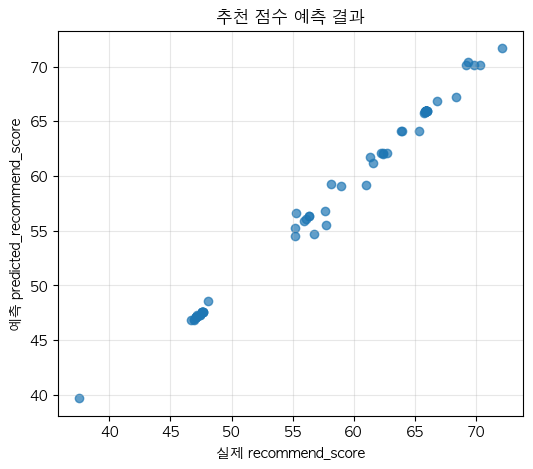

In [16]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, pred, alpha=0.7)
plt.xlabel('실제 recommend_score')
plt.ylabel('예측 predicted_recommend_score')
plt.title('추천 점수 예측 결과')
plt.grid(True, alpha=0.3)
plt.show()


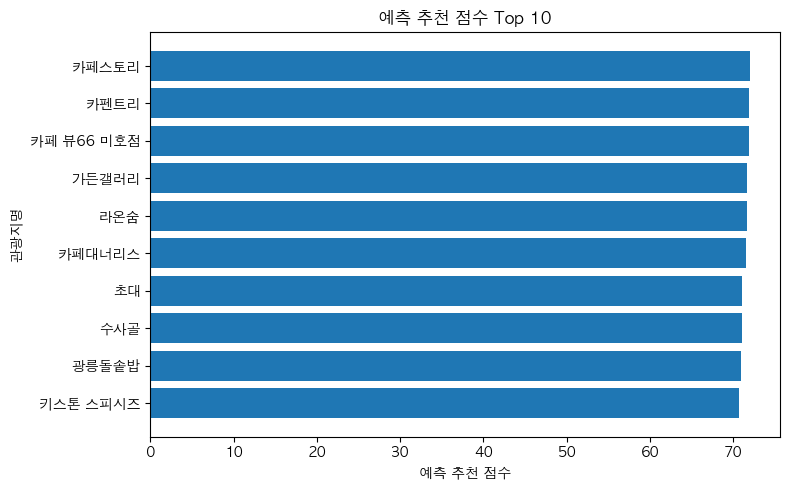

In [17]:
plot_top10 = top10.sort_values('predicted_recommend_score', ascending=True)
plt.figure(figsize=(8,5))
plt.barh(plot_top10['title'], plot_top10['predicted_recommend_score'])
plt.xlabel('예측 추천 점수')
plt.ylabel('관광지명')
plt.title('예측 추천 점수 Top 10')
plt.tight_layout()
plt.show()


## 9. 변수 중요도 확인

In [18]:
perm = permutation_importance(reg, X_test, y_test, n_repeats=5, random_state=42, scoring='neg_mean_absolute_error')
importance_df = pd.DataFrame({'feature': FEATURES, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
importance_df.head(15)


,feature,importance
24,type_prob_음식,2.797309
3,type_quality_score,2.783119
2,nav_score,2.062323
1,recent_score,1.619724
28,target_tourism_type,1.438509
29,type_top1,1.304018
27,content_type_name,1.013212
22,type_prob_숙박,0.164868
21,type_prob_쇼핑,0.124180
0,info_score,0.046736


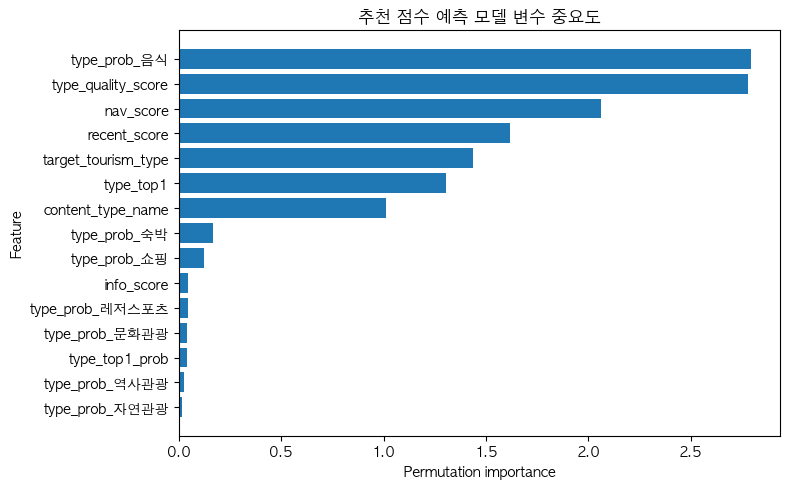

In [19]:
imp_plot = importance_df.head(15).sort_values('importance', ascending=True)
plt.figure(figsize=(8,5))
plt.barh(imp_plot['feature'], imp_plot['importance'])
plt.xlabel('Permutation importance')
plt.ylabel('Feature')
plt.title('추천 점수 예측 모델 변수 중요도')
plt.tight_layout()
plt.show()


## 10. 결과 저장

In [20]:
full_output_path = MODEL2_OUTPUT_DIR / 'model2_recommend_score_dataset.csv'
top10_path = MODEL2_OUTPUT_DIR / 'model2_top10_recommendations.csv'
model_path = MODEL2_OUTPUT_DIR / 'model2_recommend_score_regressor.joblib'
metrics_path = MODEL2_OUTPUT_DIR / 'model2_results.json'
importance_path = MODEL2_OUTPUT_DIR / 'model2_feature_importance.csv'
save_cols=[]
for col in result_cols + score_cols + prob_cols + FEATURES:
    if col in df.columns and col not in save_cols: save_cols.append(col)
for col in ['contentid','title','addr1','mapx','mapy']:
    if col in df.columns and col not in save_cols: save_cols.insert(0, col)
df.sort_values('recommend_rank')[save_cols].to_csv(full_output_path, index=False, encoding='utf-8-sig')
top10.to_csv(top10_path, index=False, encoding='utf-8-sig')
importance_df.to_csv(importance_path, index=False, encoding='utf-8-sig')
joblib.dump(reg, model_path)
results = {'metrics':metrics, 'weights':WEIGHTS, 'numeric_features':numeric_features, 'categorical_features':categorical_features, 'target':TARGET, 'note':'recommend_score는 실제 사용자 평점이 아니라 공공데이터 기반 의사 라벨입니다. 중심지 거리 변수는 제외했습니다.'}
with open(metrics_path, 'w', encoding='utf-8') as f: json.dump(results, f, ensure_ascii=False, indent=2)
print('저장 완료')
print(full_output_path); print(top10_path); print(model_path); print(metrics_path); print(importance_path)


저장 완료
recommend_score_model_outputs/model2_recommend_score_dataset.csv
recommend_score_model_outputs/model2_top10_recommendations.csv
recommend_score_model_outputs/model2_recommend_score_regressor.joblib
recommend_score_model_outputs/model2_results.json
recommend_score_model_outputs/model2_feature_importance.csv


## 11. 보고서용 요약 문장

본 모델은 모델 1에서 생성한 관광지 유형별 확률값을 입력 변수로 활용하여 관광지별 추천 점수를 예측하였다. 추천 점수는 실제 사용자 평점 데이터가 부재한 한계를 보완하기 위해 내비게이션 목적지 검색 관심도, 관광지 유형 적합도, 유형 예측 확률, 정보 완성도, 데이터 최신성, 지역 관광 수요 지표를 가중합하여 생성하였다. 중심지와의 거리 변수는 제외하였으며, 관광지의 복합적인 유형 특성과 관광 수요 데이터를 함께 반영하는 방식으로 추천 점수 예측 모델을 구성하였다.


In [21]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# ============================================
# 추천 점수 예측 모델 비교
# ============================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from catboost import CatBoostRegressor

# XGBoost 사용 가능할 때만 포함
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except Exception as e:
    print("XGBoost import 실패:", e)
    xgboost_available = False


# --------------------------------------------
# 1. 비교 모델 정의
# --------------------------------------------

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        max_depth=8,
        min_samples_leaf=2,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=400,
        random_state=42,
        max_depth=8,
        min_samples_leaf=2,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )
}

if xgboost_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )


# --------------------------------------------
# 2. 학습 및 평가
# --------------------------------------------

results = []
trained_models = {}

for model_name, model in models.items():
    print(f"\n==============================")
    print(f"{model_name} 학습 시작")
    print(f"==============================")

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = pipe

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")


# --------------------------------------------
# 3. 모델 비교 결과표
# --------------------------------------------

result_df = pd.DataFrame(results)

# 회귀에서는 MAE/RMSE는 낮을수록 좋고, R2는 높을수록 좋음
result_df = result_df.sort_values(
    by=["MAE", "RMSE", "R2"],
    ascending=[True, True, False]
).reset_index(drop=True)

result_df


RandomForest 학습 시작
MAE  : 0.2855
RMSE : 0.5952
R2   : 0.9950

ExtraTrees 학습 시작
MAE  : 0.2405
RMSE : 0.5701
R2   : 0.9954

GradientBoosting 학습 시작
MAE  : 0.1921
RMSE : 0.3823
R2   : 0.9980

HistGradientBoosting 학습 시작
MAE  : 0.2758
RMSE : 0.5195
R2   : 0.9962

CatBoost 학습 시작
MAE  : 0.3119
RMSE : 0.6961
R2   : 0.9932

XGBoost 학습 시작
MAE  : 0.1861
RMSE : 0.4200
R2   : 0.9975


,model,MAE,RMSE,R2
0,XGBoost,0.186140,0.420033,0.997526
1,GradientBoosting,0.192106,0.382326,0.997951
2,ExtraTrees,0.240533,0.570136,0.995443
3,HistGradientBoosting,0.275845,0.519518,0.996216
4,RandomForest,0.285468,0.595160,0.995034
5,CatBoost,0.311911,0.696068,0.993207
